# Agrupamento: BSAS + K-Means, Parzen e KNN

Este notebook resolve a tarefa em tres partes:

1. BSAS e usado para estimar o numero de grupos a partir da curva `k(tau)`.
   Depois, o K-Means usa esse `k` para particionar os dados.
2. Um metodo baseado em Janelas de Parzen e implementado como busca de modos
   de densidade, parecido com Mean Shift.
3. Um metodo baseado em KNN e implementado como componentes conexas de um
   grafo de vizinhos mais proximos compartilhados.

A avaliacao e qualitativa: as figuras comparam os agrupamentos encontrados
com as classes esperadas dos datasets Iris e Wine em uma projecao PCA 2D.
As metricas ARI, NMI e Silhouette sao exibidas apenas como apoio numerico.



## Dependencias

Se algum pacote estiver faltando, rode em uma celula separada:

```python
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy
```



In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ASSETS_DIR = Path("assets")
PCA_SUPTITLE_FONTSIZE = 20
PCA_TITLE_FONTSIZE = 16
PCA_LABEL_FONTSIZE = 14
PCA_TICK_FONTSIZE = 12
PCA_LEGEND_FONTSIZE = 10

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")




## Funcoes auxiliares



In [3]:
def pairwise_upper_distances(X):
    """Retorna as distancias par-a-par sem a diagonal."""
    D = pairwise_distances(X)
    return D[np.triu_indices_from(D, k=1)]


def relabel_by_size(labels):
    """Renomeia rotulos para 0, 1, 2... ordenando clusters do maior ao menor."""
    labels = np.asarray(labels)
    counts = Counter(labels)
    ordered = [lab for lab, _ in sorted(counts.items(), key=lambda item: (-item[1], item[0]))]
    mapping = {old: new for new, old in enumerate(ordered)}
    return np.array([mapping[lab] for lab in labels], dtype=int)


def merge_small_clusters_to_nearest(X, labels, min_cluster_size=3):
    """Une clusters muito pequenos ao cluster grande mais proximo."""
    labels = np.asarray(labels).copy()

    while True:
        unique, counts = np.unique(labels, return_counts=True)
        if len(unique) <= 1:
            break

        small = unique[counts < min_cluster_size]
        large = unique[counts >= min_cluster_size]
        if len(small) == 0:
            break

        if len(large) == 0:
            largest = unique[np.argmax(counts)]
            large = np.array([largest])
            small = np.array([lab for lab in unique if lab != largest])

        centroids = {lab: X[labels == lab].mean(axis=0) for lab in large}
        for lab in small:
            idx = np.where(labels == lab)[0]
            if len(idx) == 0:
                continue

            centroid = X[idx].mean(axis=0)
            target = min(large, key=lambda candidate: np.linalg.norm(centroid - centroids[candidate]))
            labels[idx] = target

    return relabel_by_size(labels)


def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    k = len(np.unique(labels))
    if k < 2 or k >= len(labels):
        return np.nan
    try:
        return silhouette_score(X, labels)
    except ValueError:
        return np.nan


def clustering_report(X, y_true, labels_by_method):
    rows = []
    for method, labels in labels_by_method.items():
        labels = np.asarray(labels)
        rows.append(
            {
                "metodo": method,
                "grupos": len(np.unique(labels)),
                "ARI vs classes": adjusted_rand_score(y_true, labels),
                "NMI vs classes": normalized_mutual_info_score(y_true, labels),
                "Silhouette": safe_silhouette(X, labels),
            }
        )

    return pd.DataFrame(rows).sort_values("ARI vs classes", ascending=False).reset_index(drop=True)


def save_figure(fig, filename):
    ASSETS_DIR.mkdir(exist_ok=True)
    fig.savefig(ASSETS_DIR / filename, dpi=220, bbox_inches="tight")


def scatter_clusters(ax, Z, labels, title):
    labels = np.asarray(labels)
    unique = np.unique(labels)
    palette_name = "tab10" if len(unique) <= 10 else "husl"
    palette = sns.color_palette(palette_name, n_colors=len(unique))

    for color, lab in zip(palette, unique):
        mask = labels == lab
        ax.scatter(
            Z[mask, 0],
            Z[mask, 1],
            s=62,
            alpha=0.88,
            color=color,
            edgecolor="white",
            linewidth=0.45,
            label=str(lab),
        )

    ax.set_title(title, fontsize=PCA_TITLE_FONTSIZE, pad=10)
    ax.set_xlabel("PC1", fontsize=PCA_LABEL_FONTSIZE)
    ax.set_ylabel("PC2", fontsize=PCA_LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=PCA_TICK_FONTSIZE)
    if len(unique) <= 10:
        ax.legend(
            title="rotulo",
            loc="best",
            fontsize=PCA_LEGEND_FONTSIZE,
            title_fontsize=PCA_LEGEND_FONTSIZE,
        )


def plot_cluster_comparison(X, y_true, labels_by_method, dataset_name):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    Z = pca.fit_transform(X)
    explained = pca.explained_variance_ratio_.sum()

    ncols = len(labels_by_method) + 1
    if ncols <= 2:
        nrows, grid_cols = 1, ncols
        figsize = (5.8 * ncols, 5.2)
    else:
        grid_cols = 2
        nrows = int(np.ceil(ncols / grid_cols))
        figsize = (11.6, 5.4 * nrows)

    fig, axes = plt.subplots(nrows, grid_cols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.16, h_pad=0.22, wspace=0.12, hspace=0.16)
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[ncols:]:
        ax.set_visible(False)

    scatter_clusters(axes[0], Z, y_true, "Classes esperadas")
    for ax, (method, labels) in zip(axes[1:], labels_by_method.items()):
        k = len(np.unique(labels))
        scatter_clusters(ax, Z, labels, f"{method}\n{k} grupos")

    fig.suptitle(
        f"{dataset_name}: comparacao em PCA 2D ({explained:.1%} da variancia)",
        fontsize=PCA_SUPTITLE_FONTSIZE,
    )
    save_figure(fig, f"comparacao_{dataset_name.lower()}_pca.png")
    plt.show()




## 1. BSAS para estimar `k`, depois K-Means para particionar

Ideia principal:

- `tau` pequeno: o BSAS cria muitos grupos, pois quase nenhum ponto fica
  perto o bastante dos representantes ja existentes.
- `tau` grande: o BSAS cria poucos grupos, pois muitos pontos passam a ser
  aceitos em grupos ja criados.
- A curva `k(tau)` costuma ter degraus. Regioes estaveis, onde `k` quase nao
  muda, sugerem valores de `k` mais robustos. Transicoes bruscas aparecem como
  valores altos da derivada numerica aproximada.

O BSAS depende da ordem dos dados. Por isso, para cada `tau`, o codigo roda
varias execucoes com embaralhamentos diferentes e usa a mediana do numero de
grupos.



In [4]:
def bsas(X, tau, max_clusters=None, shuffle=True, random_state=RANDOM_STATE):
    """
    Basic Sequential Algorithmic Scheme.

    Parametros:
    - X: matriz de dados ja padronizada.
    - tau: limiar de criacao de novo grupo.
    - max_clusters: limite opcional de grupos.
    - shuffle: embaralha a ordem para reduzir vies da ordem original.

    Retorna:
    - labels: rotulo de cada amostra.
    - centroids: representantes finais dos grupos.
    """
    X = np.asarray(X)
    n_samples = X.shape[0]
    if max_clusters is None:
        max_clusters = n_samples

    order = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(order)

    labels = np.full(n_samples, -1, dtype=int)
    centroids = []
    counts = []

    first = order[0]
    centroids.append(X[first].copy())
    counts.append(1)
    labels[first] = 0

    for idx in order[1:]:
        C = np.vstack(centroids)
        distances = np.linalg.norm(C - X[idx], axis=1)
        nearest = int(np.argmin(distances))

        if distances[nearest] > tau and len(centroids) < max_clusters:
            labels[idx] = len(centroids)
            centroids.append(X[idx].copy())
            counts.append(1)
        else:
            labels[idx] = nearest
            counts[nearest] += 1
            eta = 1.0 / counts[nearest]
            centroids[nearest] = centroids[nearest] + eta * (X[idx] - centroids[nearest])

    return relabel_by_size(labels), np.vstack(centroids)


def bsas_count_for_tau(X, tau, repeats=9, random_state=RANDOM_STATE, max_clusters=None):
    counts = []
    for rep in range(repeats):
        labels, _ = bsas(
            X,
            tau=tau,
            max_clusters=max_clusters,
            shuffle=True,
            random_state=random_state + rep,
        )
        counts.append(len(np.unique(labels)))
    return int(round(np.median(counts)))


def bsas_tau_curve(
    X,
    n_taus=90,
    q_low=2,
    q_high=90,
    repeats=9,
    random_state=RANDOM_STATE,
    max_clusters=None,
):
    distances = pairwise_upper_distances(X)
    tau_min, tau_max = np.quantile(distances, [q_low / 100, q_high / 100])
    taus = np.linspace(tau_min, tau_max, n_taus)

    k_values = np.array(
        [
            bsas_count_for_tau(
                X,
                tau=tau,
                repeats=repeats,
                random_state=random_state,
                max_clusters=max_clusters,
            )
            for tau in taus
        ],
        dtype=int,
    )

    derivative = np.gradient(k_values.astype(float), taus)
    return pd.DataFrame(
        {
            "tau": taus,
            "k_bsas": k_values,
            "dk_dtau": derivative,
            "abs_dk_dtau": np.abs(derivative),
        }
    )


def plateau_candidates(curve, min_k=2, max_k=12):
    ks = curve["k_bsas"].to_numpy()
    taus = curve["tau"].to_numpy()
    rows = []

    start = 0
    for stop in range(1, len(ks) + 1):
        changed = stop == len(ks) or ks[stop] != ks[start]
        if not changed:
            continue

        k = int(ks[start])
        length = stop - start
        tau_start = float(taus[start])
        tau_end = float(taus[stop - 1])
        width = tau_end - tau_start

        if min_k <= k <= max_k:
            mean_abs_derivative = float(curve["abs_dk_dtau"].iloc[start:stop].mean())
            left_jump = abs(int(ks[start - 1]) - k) if start > 0 else 0
            right_jump = abs(k - int(ks[stop])) if stop < len(ks) else 0
            transition_strength = max(left_jump, right_jump)

            # O fator log(1+k) evita escolher automaticamente solucoes muito
            # triviais, como k=2, apenas porque aparecem em tau muito grande.
            score = width * np.log1p(k) * (1.0 + 0.05 * transition_strength)
            score = score / (1.0 + mean_abs_derivative)

            rows.append(
                {
                    "k": k,
                    "tau_inicio": tau_start,
                    "tau_fim": tau_end,
                    "largura_tau": width,
                    "pontos_no_plateau": length,
                    "derivada_abs_media": mean_abs_derivative,
                    "forca_transicao": transition_strength,
                    "score": score,
                }
            )

        start = stop

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)


def choose_k_from_bsas_curve(curve, min_k=2, max_k=12):
    candidates = plateau_candidates(curve, min_k=min_k, max_k=max_k)

    if not candidates.empty:
        chosen = candidates.iloc[0].to_dict()
        return int(chosen["k"]), chosen, candidates

    valid = curve[(curve["k_bsas"] >= min_k) & (curve["k_bsas"] <= max_k)]
    if valid.empty:
        idx = curve["abs_dk_dtau"].idxmin()
    else:
        idx = valid["abs_dk_dtau"].idxmin()

    row = curve.loc[idx]
    chosen = {
        "k": int(row["k_bsas"]),
        "tau_inicio": float(row["tau"]),
        "tau_fim": float(row["tau"]),
        "largura_tau": 0.0,
        "pontos_no_plateau": 1,
        "derivada_abs_media": float(row["abs_dk_dtau"]),
        "forca_transicao": 0,
        "score": 0.0,
    }
    return int(chosen["k"]), chosen, candidates


def bsas_kmeans_pipeline(X, max_k=12, random_state=RANDOM_STATE):
    curve = bsas_tau_curve(X, repeats=9, random_state=random_state, max_clusters=None)
    k, chosen, candidates = choose_k_from_bsas_curve(curve, min_k=2, max_k=max_k)

    model = KMeans(n_clusters=k, n_init=50, random_state=random_state)
    labels = relabel_by_size(model.fit_predict(X))

    info = {
        "k": k,
        "chosen": chosen,
        "candidates": candidates,
        "curve": curve,
        "kmeans_model": model,
    }
    return labels, info


def plot_bsas_curve(curve, info, dataset_name):
    chosen = info["chosen"]
    k = info["k"]

    fig, ax1 = plt.subplots(figsize=(8.8, 4.2))
    ax1.step(curve["tau"], curve["k_bsas"], where="mid", color="#1f77b4", linewidth=2)
    ax1.scatter(curve["tau"], curve["k_bsas"], color="#1f77b4", s=18)
    ax1.axhline(k, color="#d62728", linestyle="--", linewidth=1.5, label=f"k escolhido = {k}")
    ax1.axvspan(chosen["tau_inicio"], chosen["tau_fim"], color="#d62728", alpha=0.12)
    ax1.set_xlabel("tau")
    ax1.set_ylabel("numero de grupos no BSAS")
    ax1.set_title(f"{dataset_name}: curva k(tau) do BSAS")
    ax1.legend(loc="upper right")

    ax2 = ax1.twinx()
    ax2.plot(curve["tau"], curve["abs_dk_dtau"], color="#444444", alpha=0.45, linewidth=1.4)
    ax2.set_ylabel("|derivada numerica|")

    plt.show()




## 2a. Agrupamento com Janelas de Parzen

Proposta: estimar uma densidade com kernel Gaussiano e mover cada ponto na
direcao de maior densidade, usando a media ponderada pelos pesos do kernel.
Pontos que convergem para o mesmo modo de densidade recebem o mesmo rotulo.

Isso e uma implementacao simples da ideia por tras de Mean Shift, mas escrita
explicitamente a partir da estimativa de densidade de Parzen.



In [5]:
def gaussian_parzen_density(points, samples, bandwidth):
    points = np.asarray(points)
    samples = np.asarray(samples)
    diff = points[:, None, :] - samples[None, :, :]
    squared_distances = np.sum(diff * diff, axis=2)
    weights = np.exp(-0.5 * squared_distances / (bandwidth**2))
    return weights.mean(axis=1)


def estimate_bandwidth_by_quantile(X, quantile=0.22):
    distances = pairwise_upper_distances(X)
    bandwidth = float(np.quantile(distances, quantile))
    return max(bandwidth, 1e-6)


def parzen_mean_shift_clustering(
    X,
    bandwidth=None,
    quantile=0.22,
    merge_factor=0.5,
    max_iter=120,
    tol=1e-4,
    min_cluster_size=None,
):
    X = np.asarray(X)
    n_samples = X.shape[0]

    if bandwidth is None:
        bandwidth = estimate_bandwidth_by_quantile(X, quantile=quantile)

    modes = np.zeros_like(X, dtype=float)
    iterations = []

    for i, start in enumerate(X):
        current = start.copy()
        for iteration in range(max_iter):
            squared_distances = np.sum((X - current) ** 2, axis=1)
            weights = np.exp(-0.5 * squared_distances / (bandwidth**2))
            weight_sum = weights.sum()
            if weight_sum <= 1e-12:
                break

            updated = (weights[:, None] * X).sum(axis=0) / weight_sum
            if np.linalg.norm(updated - current) < tol:
                current = updated
                break
            current = updated

        modes[i] = current
        iterations.append(iteration + 1)

    densities = gaussian_parzen_density(modes, X, bandwidth)
    order = np.argsort(-densities)
    merge_radius = merge_factor * bandwidth

    centers = []
    mode_labels = np.full(n_samples, -1, dtype=int)

    for idx in order:
        if not centers:
            centers.append(modes[idx].copy())
            mode_labels[idx] = 0
            continue

        C = np.vstack(centers)
        distances = np.linalg.norm(C - modes[idx], axis=1)
        nearest = int(np.argmin(distances))

        if distances[nearest] <= merge_radius:
            mode_labels[idx] = nearest
        else:
            mode_labels[idx] = len(centers)
            centers.append(modes[idx].copy())

    if min_cluster_size is None:
        min_cluster_size = max(3, int(0.02 * n_samples))

    labels = merge_small_clusters_to_nearest(X, mode_labels, min_cluster_size=min_cluster_size)
    info = {
        "bandwidth": bandwidth,
        "quantile": quantile,
        "merge_radius": merge_radius,
        "median_iterations": float(np.median(iterations)),
        "raw_modes": modes,
    }
    return labels, info




## 2b. Agrupamento com KNN

Proposta: construir um grafo em que cada ponto so se conecta a vizinhos que
sejam suficientemente parecidos em termos de vizinhanca.

Dois pontos sao conectados quando:

- sao vizinhos mutuos, isto e, um aparece na lista KNN do outro;
- compartilham pelo menos `min_shared` vizinhos entre suas listas KNN.

As componentes conexas desse grafo viram os clusters. Componentes muito
pequenas sao tratadas como ruido e anexadas ao cluster maior mais proximo.



In [6]:
class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a == root_b:
            return False

        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a
        self.parent[root_b] = root_a
        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1
        return True


def snn_knn_clustering(
    X,
    k=None,
    min_shared=None,
    mutual=True,
    min_cluster_size=None,
):
    X = np.asarray(X)
    n_samples = X.shape[0]

    if k is None:
        k = max(5, int(round(np.sqrt(n_samples))))
    k = min(k, n_samples - 1)

    if min_shared is None:
        min_shared = max(2, int(np.ceil(0.4 * k)))

    if min_cluster_size is None:
        min_cluster_size = max(3, int(0.02 * n_samples))

    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    neighbors = indices[:, 1:]
    neighbor_sets = [set(row) for row in neighbors]
    dsu = DisjointSet(n_samples)
    accepted_edges = 0

    for i in range(n_samples):
        for j in neighbors[i]:
            if j <= i:
                continue
            if mutual and i not in neighbor_sets[j]:
                continue

            shared = len(neighbor_sets[i].intersection(neighbor_sets[j]))
            if shared >= min_shared:
                if dsu.union(i, j):
                    accepted_edges += 1

    roots = np.array([dsu.find(i) for i in range(n_samples)])
    labels = relabel_by_size(roots)
    labels = merge_small_clusters_to_nearest(X, labels, min_cluster_size=min_cluster_size)

    info = {
        "k": k,
        "min_shared": min_shared,
        "mutual": mutual,
        "min_cluster_size": min_cluster_size,
        "accepted_edges": accepted_edges,
    }
    return labels, info




## Execucao nos datasets Iris e Wine

Os parametros abaixo nao usam os rotulos verdadeiros. Eles controlam apenas a
sensibilidade dos metodos:

- `bsas_max_k`: maior `k` considerado plausivel ao procurar plateaus do BSAS.
- `parzen_quantile`: quantil das distancias par-a-par usado como largura da
  janela de Parzen.
- `snn_k`: numero de vizinhos no metodo KNN.
- `snn_min_shared`: minimo de vizinhos compartilhados para conectar dois pontos.

Se o professor pedir analise de sensibilidade, altere esses valores e rode
novamente as celulas.



Dataset: Iris
Amostras: 150 | Atributos: 4 | Classes esperadas: 3

BSAS estimou k = 2 para o K-Means.
Melhores plateaus candidatos da curva k(tau):


,k,tau_inicio,tau_fim,largura_tau,pontos_no_plateau,derivada_abs_media,forca_transicao,score
0,2,3.154342,3.804302,0.649960,16,1.442395,1,0.306976
1,6,1.941082,2.244397,0.303315,8,2.884791,1,0.159528
2,3,2.764365,3.111011,0.346646,9,2.564259,1,0.141567
3,8,1.507775,1.767759,0.259984,7,3.296904,1,0.139590
4,4,2.504381,2.721035,0.216653,6,3.846388,1,0.075546
5,5,2.287728,2.461050,0.173323,5,4.615665,1,0.058066
6,10,1.334452,1.421114,0.086661,3,7.692776,1,0.025101
7,7,1.811090,1.897751,0.086661,3,7.692776,1,0.021767


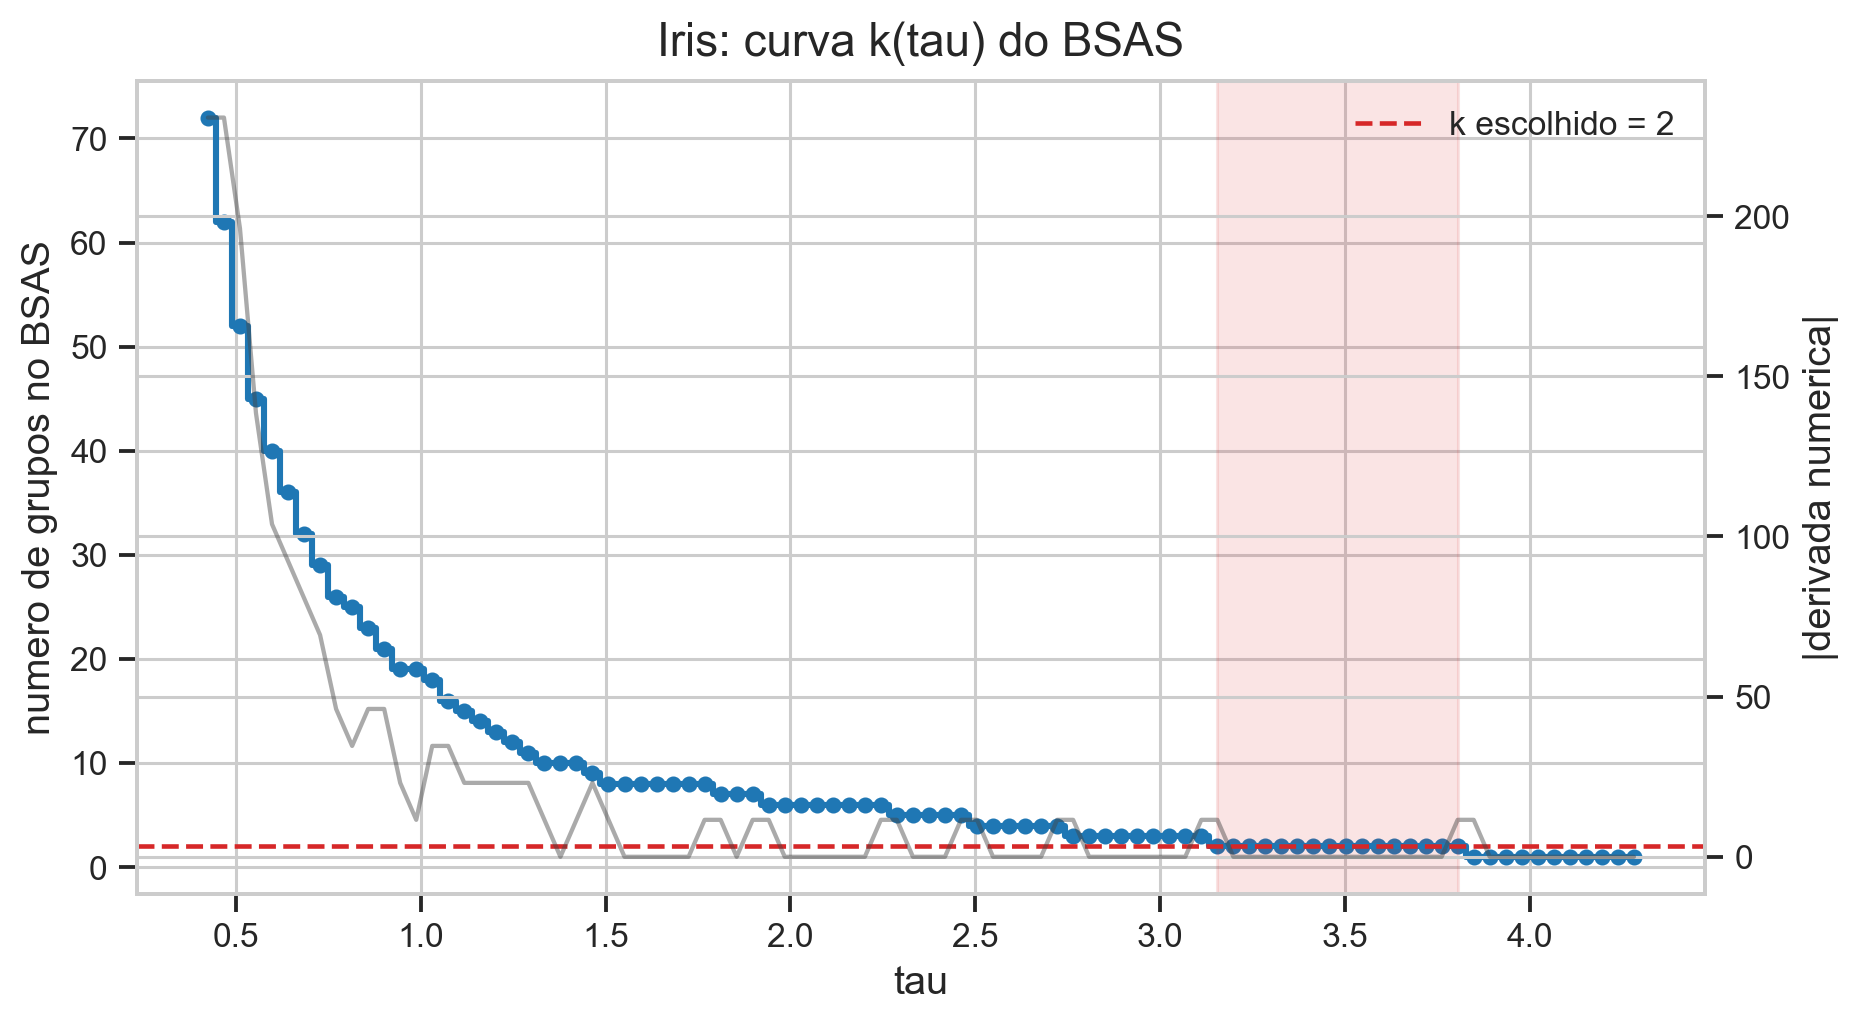

Parzen: bandwidth=1.2303, merge_radius=0.6151, grupos=1
KNN: k=10, min_shared=4, arestas=145, grupos=3

Metricas de apoio:


,metodo,grupos,ARI vs classes,NMI vs classes,Silhouette
0,BSAS -> K-Means,2,0.568116,0.733680,0.581750
1,KNN,3,0.562136,0.713099,0.480267
2,Parzen,1,0.000000,0.000000,NaN


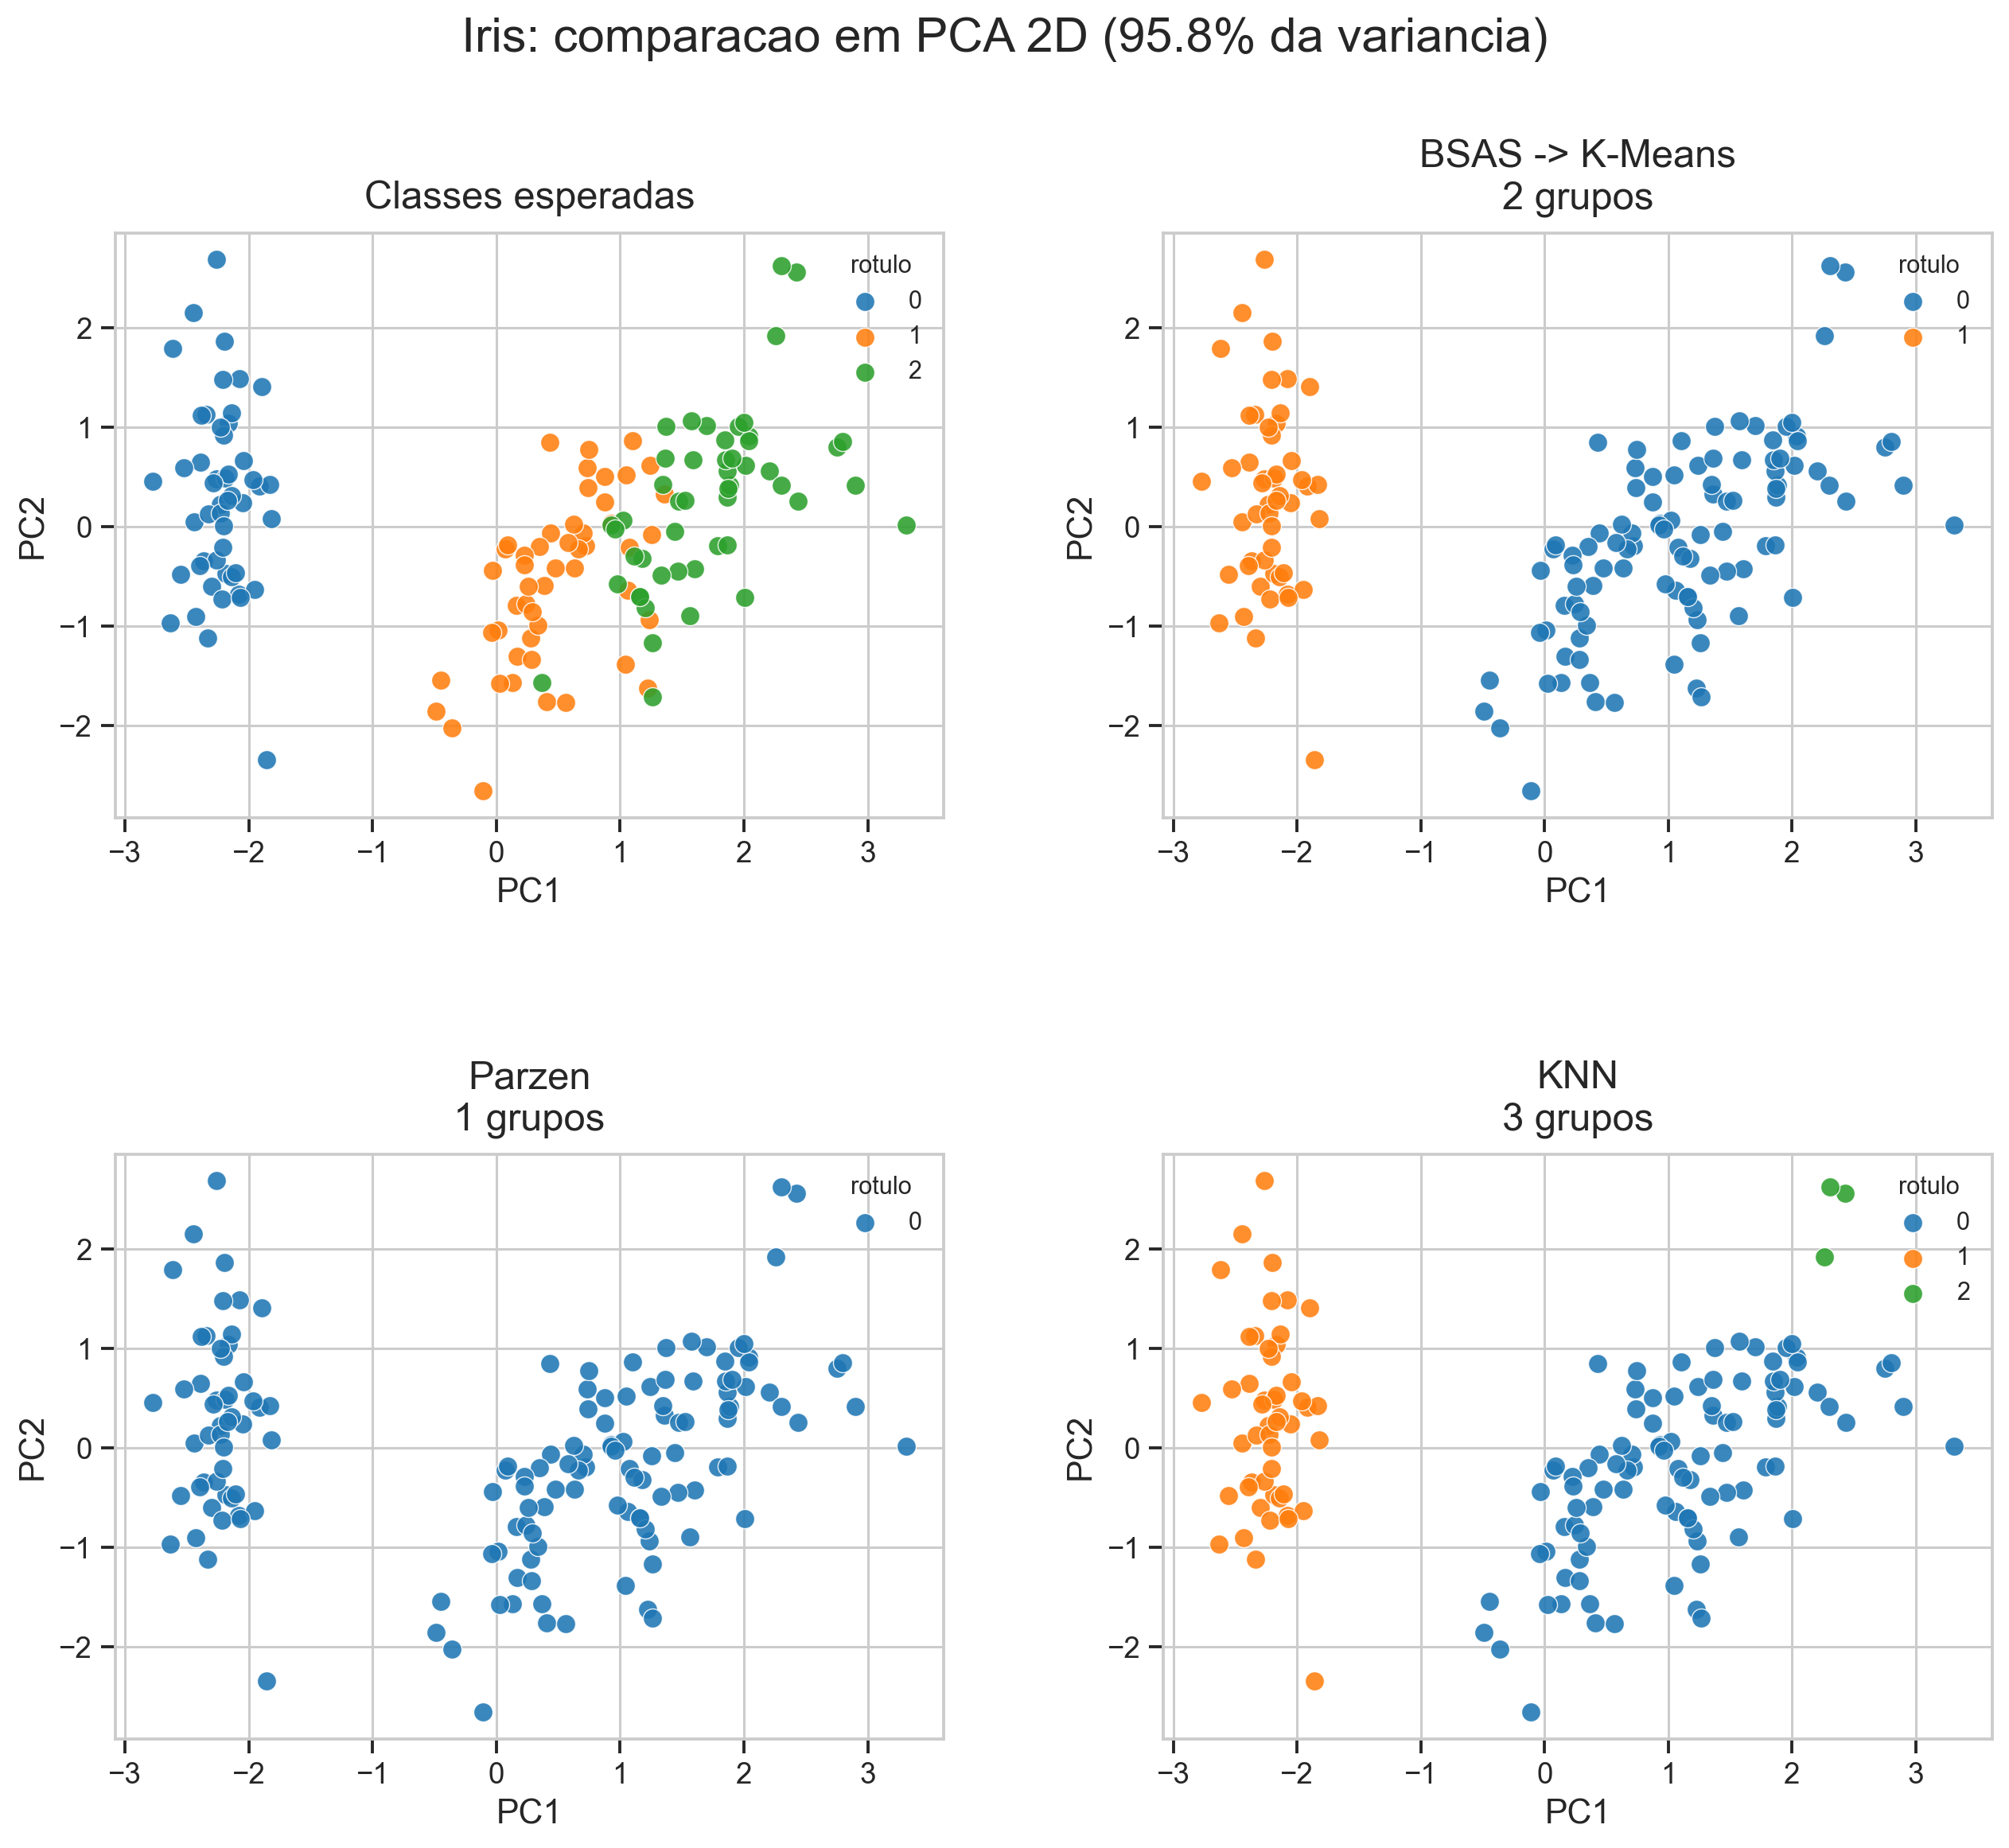

Dataset: Wine
Amostras: 178 | Atributos: 13 | Classes esperadas: 3

BSAS estimou k = 9 para o K-Means.
Melhores plateaus candidatos da curva k(tau):


,k,tau_inicio,tau_fim,largura_tau,pontos_no_plateau,derivada_abs_media,forca_transicao,score
0,9,4.543042,4.749216,0.206174,5,3.880220,1,0.102141
1,2,5.934716,6.243977,0.309261,7,2.771586,1,0.094588
2,5,5.367738,5.573912,0.206174,5,3.880220,1,0.079481
3,4,5.625455,5.831629,0.206174,5,3.880220,1,0.071393
4,7,5.006934,5.161564,0.154630,4,4.850275,1,0.057710
5,11,4.027608,4.130695,0.103087,3,6.467033,1,0.036021
6,11,4.285325,4.388412,0.103087,3,6.467033,1,0.036021
7,6,5.213107,5.316194,0.103087,3,6.467033,1,0.028208


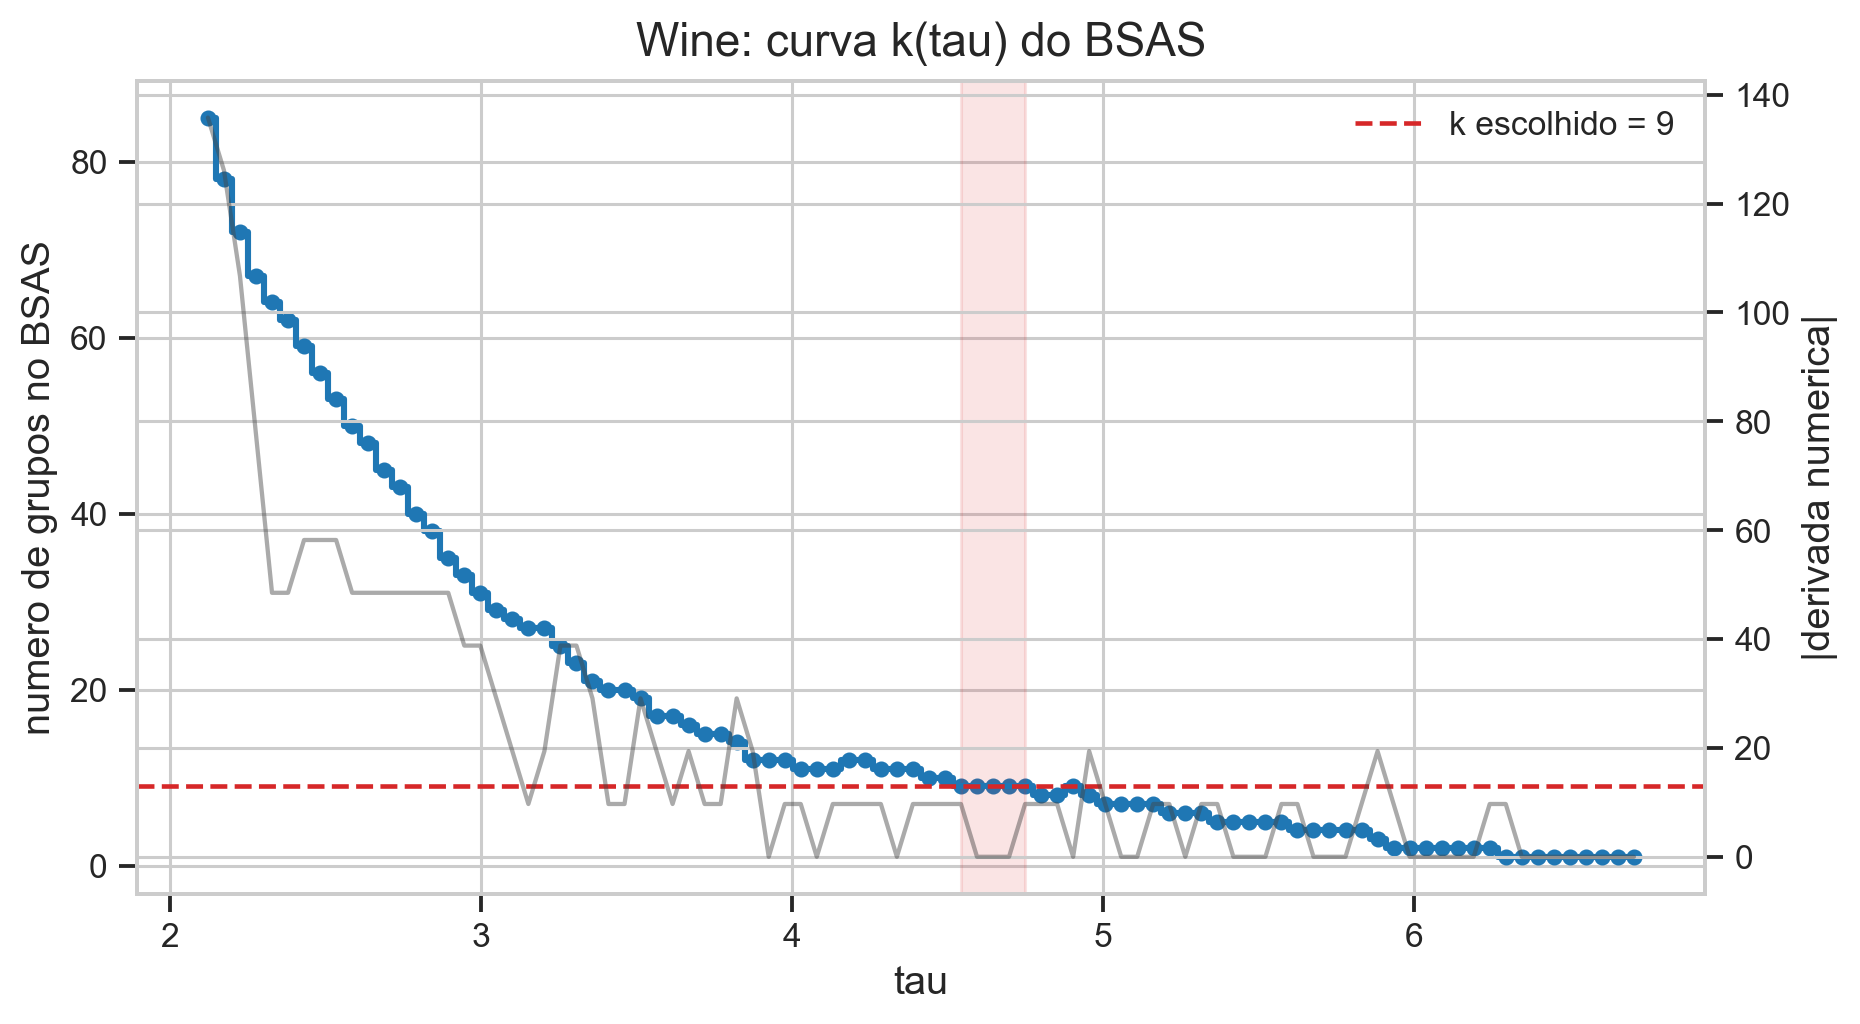

Parzen: bandwidth=3.4193, merge_radius=1.7096, grupos=1
KNN: k=12, min_shared=5, arestas=167, grupos=2

Metricas de apoio:


,metodo,grupos,ARI vs classes,NMI vs classes,Silhouette
0,BSAS -> K-Means,9,0.385931,0.589519,0.150398
1,Parzen,1,0.000000,0.000000,NaN
2,KNN,2,-0.005179,0.026817,0.222451


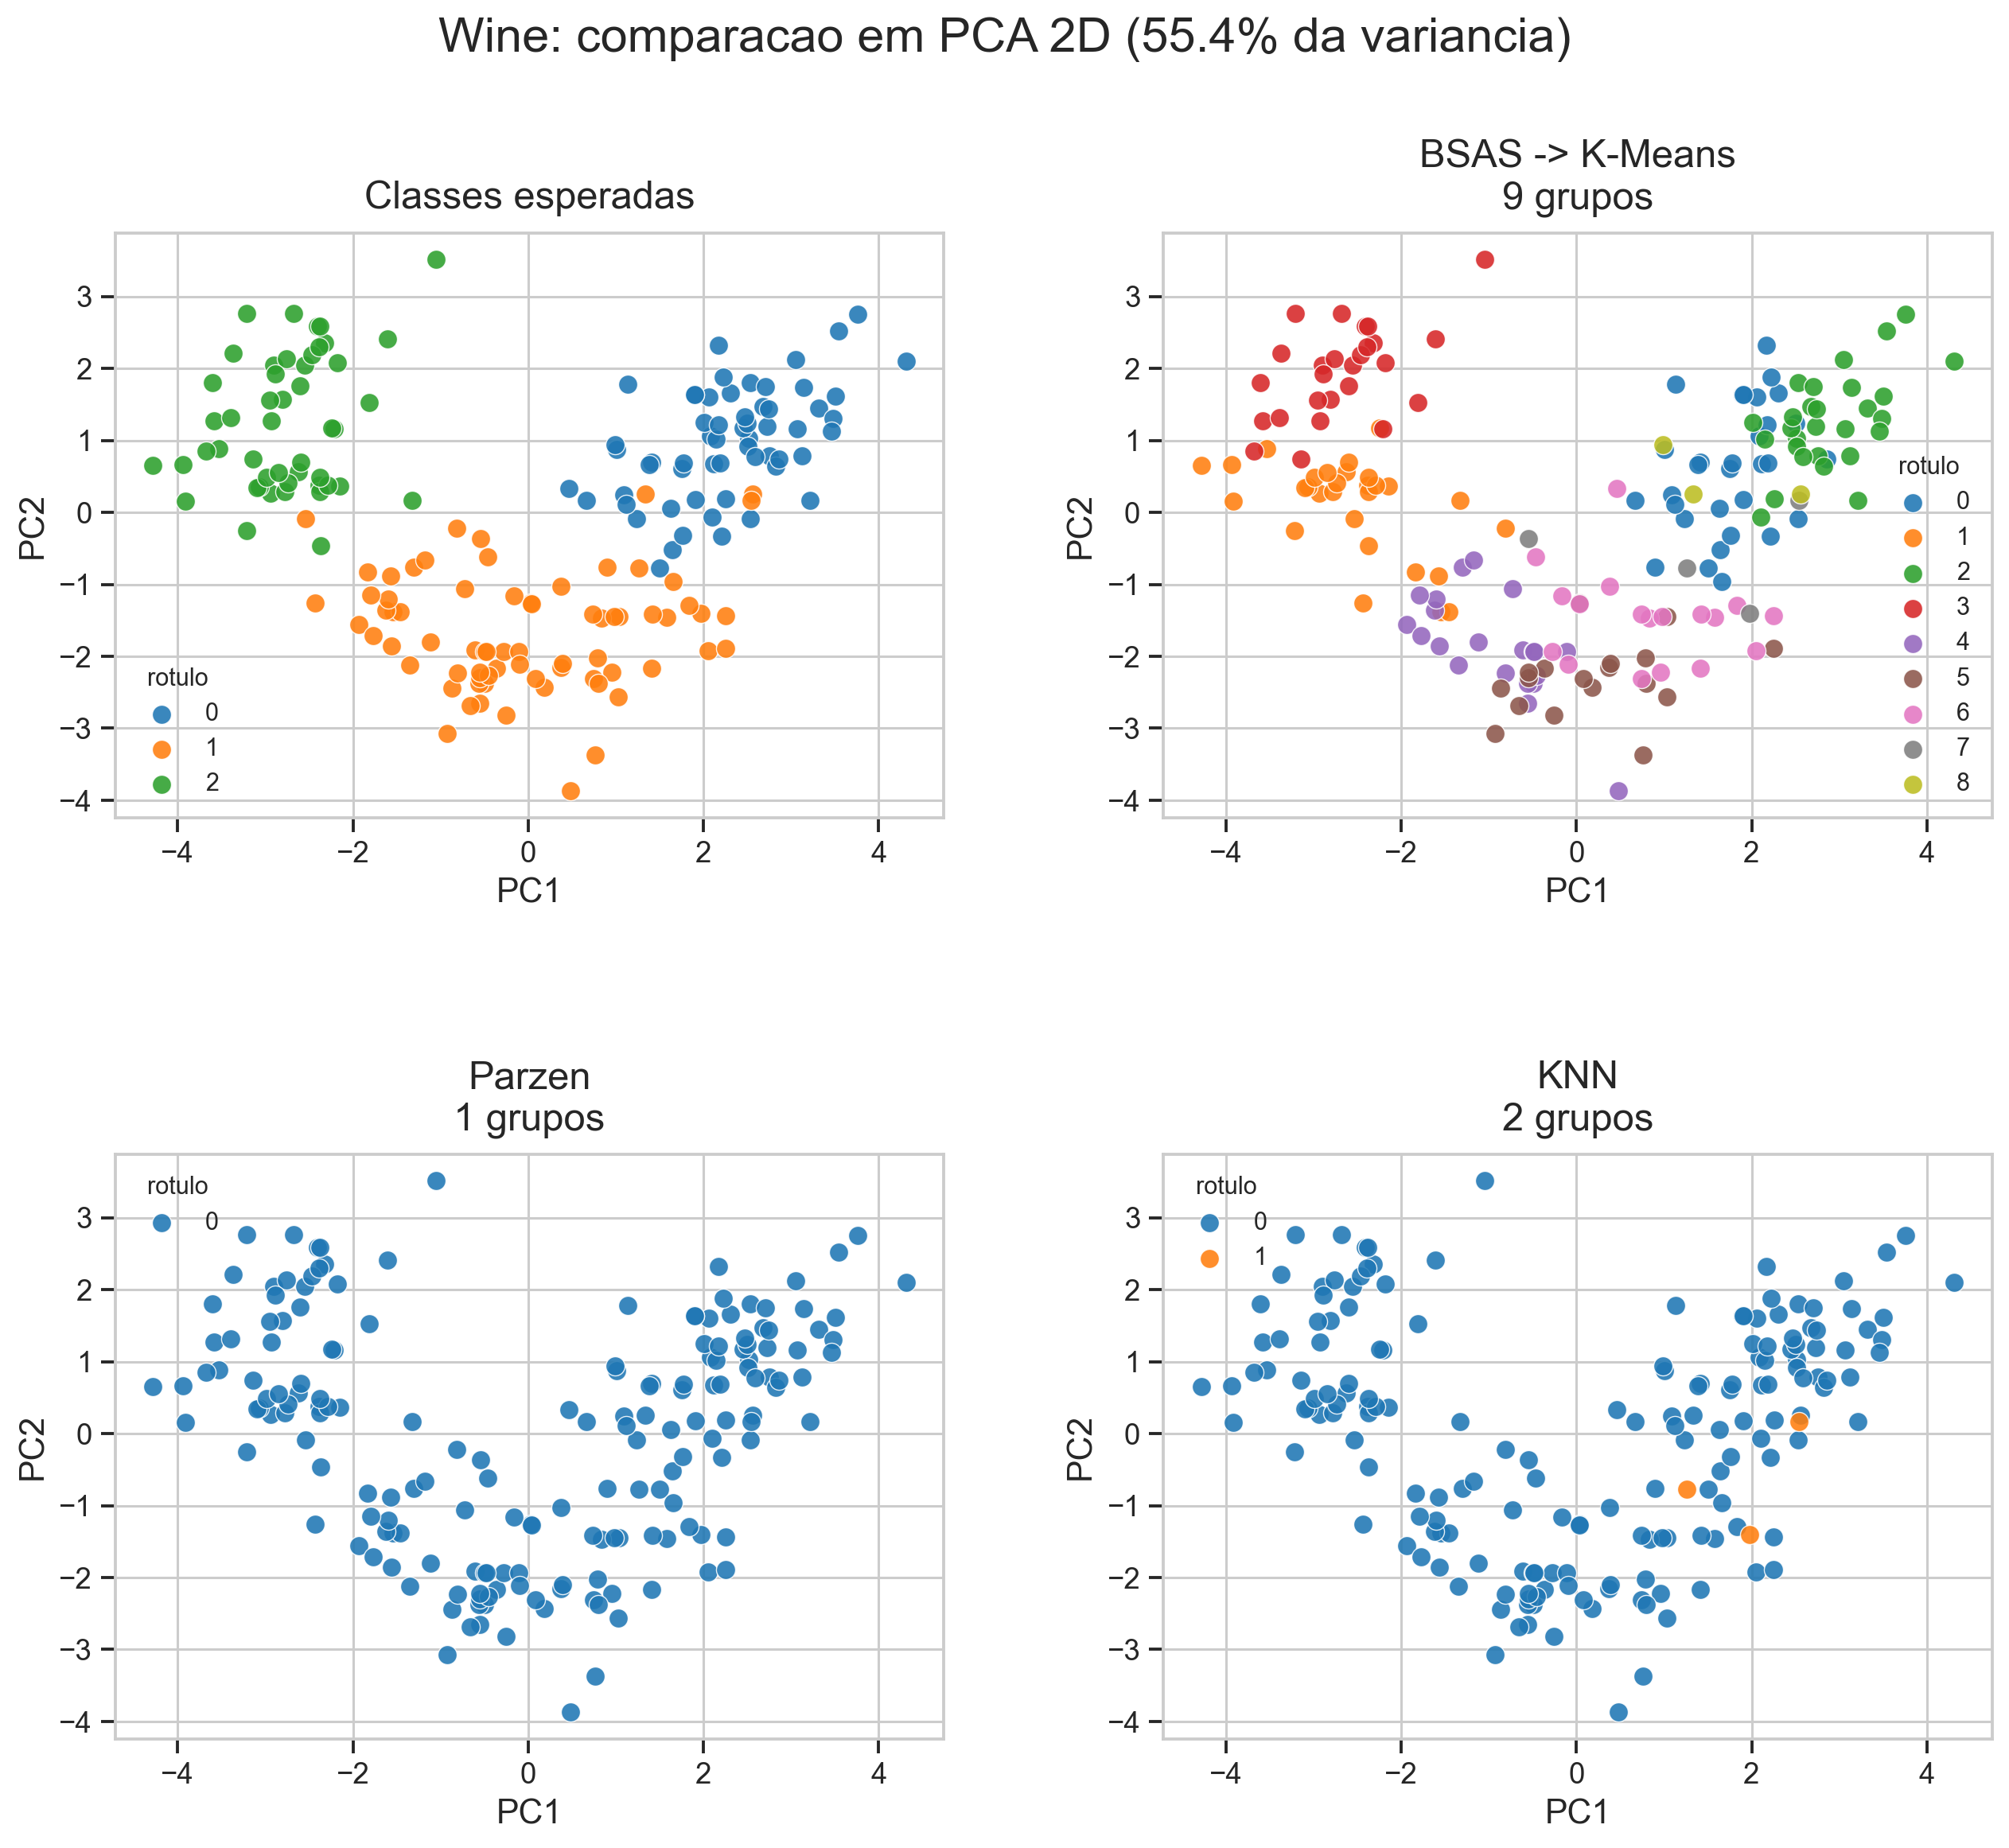

In [7]:
DATASETS = {
    "Iris": load_iris(),
    "Wine": load_wine(),
}

CONFIG = {
    "Iris": {
        "bsas_max_k": 10,
        "parzen_quantile": 0.22,
        "snn_k": 10,
        "snn_min_shared": 4,
    },
    "Wine": {
        "bsas_max_k": 12,
        "parzen_quantile": 0.18,
        "snn_k": 12,
        "snn_min_shared": 5,
    },
}

results = {}

for dataset_name, bunch in DATASETS.items():
    cfg = CONFIG[dataset_name]
    X_raw = bunch.data
    y_true = bunch.target
    X = StandardScaler().fit_transform(X_raw)

    print("=" * 90)
    print(f"Dataset: {dataset_name}")
    print(f"Amostras: {X.shape[0]} | Atributos: {X.shape[1]} | Classes esperadas: {len(np.unique(y_true))}")

    bsas_kmeans_labels, bsas_info = bsas_kmeans_pipeline(
        X,
        max_k=cfg["bsas_max_k"],
        random_state=RANDOM_STATE,
    )
    print(f"\nBSAS estimou k = {bsas_info['k']} para o K-Means.")
    print("Melhores plateaus candidatos da curva k(tau):")
    display(bsas_info["candidates"].head(8))
    plot_bsas_curve(bsas_info["curve"], bsas_info, dataset_name)

    parzen_labels, parzen_info = parzen_mean_shift_clustering(
        X,
        quantile=cfg["parzen_quantile"],
    )
    print(
        "Parzen:",
        f"bandwidth={parzen_info['bandwidth']:.4f},",
        f"merge_radius={parzen_info['merge_radius']:.4f},",
        f"grupos={len(np.unique(parzen_labels))}",
    )

    knn_labels, knn_info = snn_knn_clustering(
        X,
        k=cfg["snn_k"],
        min_shared=cfg["snn_min_shared"],
    )
    print(
        "KNN:",
        f"k={knn_info['k']},",
        f"min_shared={knn_info['min_shared']},",
        f"arestas={knn_info['accepted_edges']},",
        f"grupos={len(np.unique(knn_labels))}",
    )

    labels_by_method = {
        "BSAS -> K-Means": bsas_kmeans_labels,
        "Parzen": parzen_labels,
        "KNN": knn_labels,
    }

    print("\nMetricas de apoio:")
    display(clustering_report(X, y_true, labels_by_method))

    plot_cluster_comparison(X, y_true, labels_by_method, dataset_name)

    results[dataset_name] = {
        "X": X,
        "y_true": y_true,
        "labels_by_method": labels_by_method,
        "bsas_info": bsas_info,
        "parzen_info": parzen_info,
        "knn_info": knn_info,
    }




## Texto curto para interpretar os resultados

Use estes pontos na explicacao do trabalho:

- No BSAS, `tau` controla a tolerancia para inserir um ponto em um grupo ja
  existente. Por isso, a curva `k(tau)` tende a cair conforme `tau` aumenta.
- A derivada numerica indica regioes de transicao: quando `|dk/dtau|` e alto,
  pequenas mudancas em `tau` alteram bastante o numero de grupos. Plateaus
  com derivada pequena indicam maior estabilidade.
- Depois que o BSAS estima `k`, o K-Means faz o particionamento final. Assim,
  o BSAS nao precisa ser o agrupador definitivo; ele funciona como estimador
  do hiperparametro mais importante do K-Means.
- O metodo de Parzen procura modos da densidade estimada. Grupos sao regioes
  que convergem para o mesmo pico de densidade.
- O metodo KNN interpreta agrupamentos como componentes de um grafo local.
  Pontos sao conectados apenas quando compartilham vizinhancas semelhantes,
  o que reduz ligacoes fracas entre grupos proximos.
- Iris geralmente mostra uma classe bem separada e duas classes parcialmente
  sobrepostas. Wine costuma ficar mais bem separado apos padronizacao, mas a
  separacao depende bastante do metodo e dos parametros locais.
